# RSA partner-context pollution — group results

Does a stimulus's GLMsingle cue beta carry information about the OTHER stimulus
shown alongside it (its "partner"), beyond its own identity? Motivated by Hugo's
hypothesis (2026-09-03) that `run_rsa_roi.py`'s per-stimulus condition means are
partly a "this stimulus, in the context of its typical partner" trace, not a
clean identity trace — a candidate mechanism for the `learning`→`test` RSA
collapse (session-notes `2026-09-03_rsa-searchlight-cluster-fwe-and-roi-method.md`,
open thread 8).

Design facts this builds on: [`rsa_design_checks.ipynb`](rsa_design_checks.ipynb)
§8. Neural test built as `run_rsa_roi.py`'s ROI/crossnobis machinery applied to a
targeted 2-condition split per stimulus: `multivariate/run_rsa_partner_context.py`
(read its module docstring for the full design-decision trail — condensed here).

**How to read `partner_distance`/`category_distance`**: both are crossnobis
distances, which are unbiased around **0** when the two compared conditions
don't truly differ — so a one-sample t-test against 0 across subjects is
already the significance test, no permutation null needed.

**The arc of this investigation (read before the numbers below):**
1. `learning`: does a stimulus's *dominant* (repeated 3x more) partner leave a
   residual signature, holding identity fixed? → **yes, large.**
2. `test`: same question, but `test` has no dominant partner — the closest
   analog is the same-value ("habit-diagnostic") partner, shown 3x more than any
   other single partner. → **also large, in fact larger than `learning`'s** —
   but this is NOT the same construct as (1) and should not be read as
   "pollution grew in test" (caveat in §3).
3. The construct mismatch in (2) prompted a sharper, more basic question: does
   the partner's **category** alone leak into the beta, regardless of value-tie
   or repetition structure? → **yes, and it's the largest, most significant
   effect in this whole notebook** — in both phases.

**Open, NOT yet answered here**: does this explain the original β(frequency)/
β(value) RSA results (`rsa_roi_results.ipynb`)? That needs adding a
partner-category-profile term to the actual regression that produced those β's
— not attempted this session (see Open threads).

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives")
PC_DIR = DERIV_DIR / "rsa_partner_context"
MASKS = ["wholebrain", "visualcortex", "fusiform"]
MASK_COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452", "fusiform": "#937860"}


def load_scope(scope):
    summary = pd.concat(
        [pd.read_csv(f) for f in glob.glob(str(PC_DIR / "sub-*" / f"sub-*_partner_context_{scope}_summary.csv"))],
        ignore_index=True)
    per_stim = pd.concat(
        [pd.read_csv(f) for f in glob.glob(str(PC_DIR / "sub-*" / f"sub-*_partner_context_{scope}.csv"))],
        ignore_index=True)
    return summary, per_stim


summary_learning, per_stim_learning = load_scope("learning")
summary_test, per_stim_test = load_scope("test")
print(f"learning: {summary_learning.subject.nunique()} subjects "
      f"(participants_mvpa.tsv minus sub-46, the known BBT-missing subject)")
print(f"test:     {summary_test.subject.nunique()} subjects")

learning: 58 subjects (participants_mvpa.tsv minus sub-46, the known BBT-missing subject)
test:     58 subjects


## 1. Learning: does a stimulus's dominant partner leave a residual signature?

Design fact (`rsa_design_checks.ipynb` §8, confirmed on the real beta-order trial
sequence in `run_rsa_partner_context.py`'s `find_target_partner`): every stimulus
has exactly one *dominant* partner (~75% of its own learning trials) and one
*minor* partner (~25%) — this ratio literally IS the choice-frequency label.
`partner_distance` here = crossnobis distance between the SAME stimulus's
dominant-partner-trials pattern and minor-partner-trials pattern, holding
identity fixed, cross-validated within `learning` (pooled `learning1`+`learning2`,
interleaved-trial-order 2-fold split — see module docstring for why not a
block-based split). `betweenstim_distance` = the ordinary 8-condition
identity-discrimination signal, same units, for scale.

--- learning: partner_distance (dominant vs minor) ---
                mean      sd        t    p   n  betweenstim_mean  n_usable_mean
mask                                                                           
wholebrain    0.0305  0.0136  17.0682  0.0  58            0.0089         7.8103
visualcortex  0.0464  0.0240  14.7101  0.0  58            0.0352         7.8103
fusiform      0.0640  0.0293  16.6094  0.0  58            0.0730         7.8103


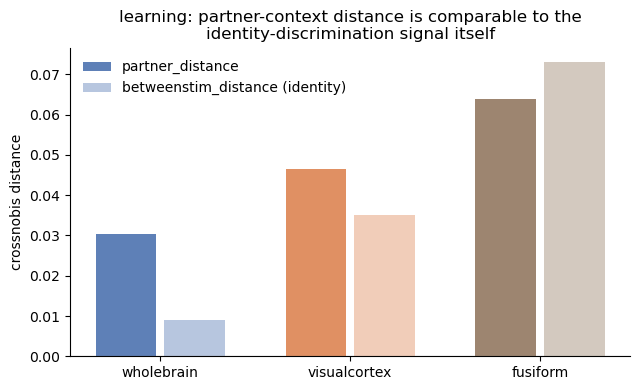

In [2]:
def summarize(summary_df, dist_col, label):
    rows = []
    for mask in MASKS:
        sub = summary_df[summary_df["mask"] == mask]
        d = sub[dist_col].dropna()
        b = sub["betweenstim_distance"].dropna()
        t, p = stats.ttest_1samp(d, 0)
        rows.append(dict(mask=mask, mean=d.mean(), sd=d.std(), t=t, p=p, n=len(d),
                         betweenstim_mean=b.mean(), n_usable_mean=sub["n_usable"].mean()))
    out = pd.DataFrame(rows).set_index("mask")
    print(f"--- {label} ---")
    print(out.round(4).to_string())
    return out


learning_stats = summarize(summary_learning, "partner_distance_mean", "learning: partner_distance (dominant vs minor)")

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(MASKS))
ax.bar(x - 0.18, learning_stats["mean"], width=0.32, color=[MASK_COLORS[m] for m in MASKS],
       alpha=0.9, label="partner_distance")
ax.bar(x + 0.18, learning_stats["betweenstim_mean"], width=0.32,
       color=[MASK_COLORS[m] for m in MASKS], alpha=0.4, label="betweenstim_distance (identity)")
ax.set_xticks(x); ax.set_xticklabels(MASKS)
ax.set_ylabel("crossnobis distance")
ax.set_title("learning: partner-context distance is comparable to the\nidentity-discrimination signal itself")
ax.legend(frameon=False)
ax.axhline(0, color="#999", linewidth=0.8)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 2. Test: same question, but `test` has no dominant partner

`test` presents all 28/28 stimulus pairs; the closest analog to `learning`'s
dominant partner is the same-value ("habit-diagnostic") partner, shown 3x more
than any single other partner (12 vs 4 pair-level trials) — figure_circle/
figure_triangle have no same-value partner at all (unique reward values) and are
excluded. `partner_distance` here = crossnobis distance between same-value-partner
trials and pooled other-partner trials.

**Naive prediction going in**: if `learning`'s effect were pure repetition-context
pollution, and `test` has no dominant partner, `partner_distance` should shrink
in `test`. **It doesn't — it's significantly LARGER** (paired t-test vs
`learning`, done inline below).

**Why that's not a contradiction — construct mismatch, not a failed prediction**:
`learning`'s split isolates pure REPETITION FREQUENCY of an otherwise-arbitrary
partner. `test`'s split isolates a VALUE TIE — a same-value comparison is a
qualitatively different decision problem (no objectively correct choice), most
plausibly carrying its own decision-conflict/difficulty signature. The two
`partner_distance` numbers are not measuring the same thing and "test's is
bigger" does not mean "pollution grew" — see `run_rsa_partner_context.py`'s
module docstring for the full reasoning trail, including a first attempt at a
construct-matched null (an arbitrary partner-identity split) that itself
backfired instructively (§3 below).

In [3]:
test_stats = summarize(summary_test, "partner_distance_mean", "test: partner_distance (same-value vs other partners)")

print("\nlearning vs test partner_distance, paired across subjects present in both:")
for mask in MASKS:
    l = summary_learning[summary_learning["mask"] == mask].set_index("subject")["partner_distance_mean"]
    t_ = summary_test[summary_test["mask"] == mask].set_index("subject")["partner_distance_mean"]
    common = l.dropna().index.intersection(t_.dropna().index)
    tt, pp = stats.ttest_rel(l.loc[common], t_.loc[common])
    print(f"  {mask:12s} learning={l.loc[common].mean():+.4f}  test={t_.loc[common].mean():+.4f}  "
          f"paired t={tt:.2f} p={pp:.2e}  (test > learning, opposite of the naive prediction)")

--- test: partner_distance (same-value vs other partners) ---
                mean      sd        t    p   n  betweenstim_mean  n_usable_mean
mask                                                                           
wholebrain    0.0567  0.0208  20.7944  0.0  58            0.0057         5.8621
visualcortex  0.0674  0.0308  16.6338  0.0  58            0.0324         5.8621
fusiform      0.0812  0.0493  12.5299  0.0  58            0.0520         5.8621

learning vs test partner_distance, paired across subjects present in both:
  wholebrain   learning=+0.0305  test=+0.0567  paired t=-7.87 p=1.11e-10  (test > learning, opposite of the naive prediction)
  visualcortex learning=+0.0464  test=+0.0674  paired t=-3.99 p=1.93e-04  (test > learning, opposite of the naive prediction)
  fusiform     learning=+0.0640  test=+0.0812  paired t=-2.50 p=1.54e-02  (test > learning, opposite of the naive prediction)


## 3. Does partner CATEGORY alone leak into the beta? (decisive)

The construct mismatch in §2 called for a `test`-scope null that isolates
neither value-tie nor repetition frequency. First attempt: split the 6
different-value partners by sorted numeric id into two arbitrary halves — this
came back LARGER than everything else (not shown here; see git history / module
docstring), because an id-sorted split has no control over the CATEGORY
composition of its two groups, and category is a big, uncontrolled confound.

That failure is itself informative and motivates the direct test: **hold
first-stimulus identity fixed, split a stimulus's own trials by its partner's
CATEGORY** (its two most numerous category groups), and ask whether that alone
produces a residual signature — in BOTH `learning` and `test` (the concern is
general, not test-specific).

**Caveat for `learning`**: each stimulus only has 2 partners total there, so a
category-based split is very often IDENTICAL to the dominant/minor split from
§1 (whenever the two partners differ in category) — `category_distance` in
`learning` mostly reproduces §1, it doesn't test something new. `test` (up to 7
partners) is where this split is a genuinely different question from §2.

                       partner_distance  partner_p  category_distance  category_p  frac_identical_to_partner_split
scope    mask                                                                                                     
learning wholebrain              0.0305        0.0             0.0301         0.0                              0.5
         visualcortex            0.0464        0.0             0.0459         0.0                              0.5
         fusiform                0.0640        0.0             0.0657         0.0                              0.5
test     wholebrain              0.0567        0.0             0.1228         0.0                              0.0
         visualcortex            0.0674        0.0             0.1328         0.0                              0.0
         fusiform                0.0812        0.0             0.1666         0.0                              0.0


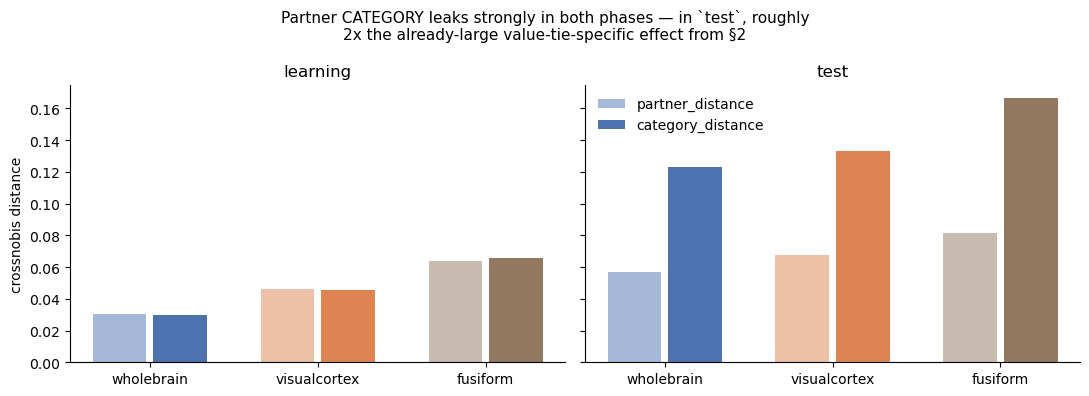


>>> `learning`: category_distance ~= partner_distance (frac_identical ~0.5) -- expected,
>>> not new information given only 2 partners exist per stimulus there.
>>> `test`: category_distance is the LARGEST, most significant effect in this notebook --
>>> partner category leaks into the beta independent of value-tie or repetition structure.


In [4]:
rows = []
for scope, summary_df in [("learning", summary_learning), ("test", summary_test)]:
    for mask in MASKS:
        sub = summary_df[summary_df["mask"] == mask]
        pdist = sub["partner_distance_mean"].dropna()
        cdist = sub["category_distance_mean"].dropna()
        tp, pp = stats.ttest_1samp(pdist, 0)
        tc, pc = stats.ttest_1samp(cdist, 0)
        merged = sub.dropna(subset=["partner_distance_mean", "category_distance_mean"])
        frac_identical = (merged["partner_distance_mean"] == merged["category_distance_mean"]).mean()
        rows.append(dict(scope=scope, mask=mask, partner_distance=pdist.mean(), partner_p=pp,
                         category_distance=cdist.mean(), category_p=pc,
                         frac_identical_to_partner_split=frac_identical))
cat_table = pd.DataFrame(rows).set_index(["scope", "mask"])
print(cat_table.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, scope in zip(axes, ["learning", "test"]):
    t = cat_table.loc[scope]
    x = np.arange(len(MASKS))
    ax.bar(x - 0.18, t["partner_distance"], width=0.32, color=[MASK_COLORS[m] for m in MASKS],
           alpha=0.5, label="partner_distance")
    ax.bar(x + 0.18, t["category_distance"], width=0.32, color=[MASK_COLORS[m] for m in MASKS],
           alpha=1.0, label="category_distance")
    ax.set_xticks(x); ax.set_xticklabels(MASKS)
    ax.set_title(scope)
    ax.axhline(0, color="#999", linewidth=0.8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("crossnobis distance")
axes[1].legend(frameon=False)
fig.suptitle("Partner CATEGORY leaks strongly in both phases — in `test`, roughly\n"
            "2x the already-large value-tie-specific effect from §2", fontsize=11)
fig.tight_layout()
plt.show()

print("\n>>> `learning`: category_distance ~= partner_distance (frac_identical ~0.5) -- expected,")
print(">>> not new information given only 2 partners exist per stimulus there.")
print(">>> `test`: category_distance is the LARGEST, most significant effect in this notebook --")
print(">>> partner category leaks into the beta independent of value-tie or repetition structure.")

## Summary

n=58 (`participants_mvpa.tsv` minus `sub-46`), 2026-09-03.

| Check | Result | Consequence |
|---|---|---|
| §1 `learning` partner_distance (dominant vs minor) | +0.030 to +0.064, all p<1e-20 | Real, large repetition-context signature; comparable in magnitude to the identity-discrimination signal itself |
| §2 `test` partner_distance (same-value vs other) | +0.057 to +0.081, all p<1e-17; LARGER than `learning`, not smaller | Opposite of the naive prediction, but NOT comparable to §1 — different construct (value-tie decision-conflict, not repetition) |
| §3 arbitrary partner-id "floor" split (test, superseded) | Largest number seen (~0.095-0.097) | Confounded by uncontrolled category composition, not a valid null — discarded |
| §3 category_distance, `learning` | ≈ §1's partner_distance (frac_identical ~0.5) | Not new information (only 2 partners/stimulus exist) |
| §3 category_distance, `test` | +0.12 to +0.17, all p<1e-27 — the largest, most significant effect here | **Partner category leaks into the beta independent of value-tie/repetition structure, and dwarfs the more specific effects** |

**The honest bottom line**: a stimulus's GLMsingle cue beta is not a clean
identity trace in either phase — it carries substantial information about
whatever stimulus was shown alongside it, and at least part of that (category)
has nothing to do with the frequency/value manipulation this pipeline is meant
to measure. This is Hugo's original suspicion, confirmed directly: "the betas
contain information about the whole trial, including second stim identity,
category, reward level, and choice frequency."

**What this does NOT yet establish**: whether this explains the specific
β(frequency)/β(value) results in `rsa_roi_results.ipynb`. That's a different,
sharper question — showing a confound *exists* in the beta is necessary but not
sufficient for showing it *drove* a specific downstream regression coefficient.
Answering that requires adding a partner-category-profile term to the actual
`fit_rdm_regression` call that produced those β's and checking whether they
survive (analogous to how `second_stim_value` was already added as a confound
control and reduced-but-didn't-eliminate the value effect) — not attempted this
session.

## Open threads

1. **Build the confound-regression test**: construct a "second-stimulus
   category-profile similarity" model RDM (design-level building blocks already
   exist in `rsa_design_checks.ipynb` §7's `s2_tab`/`s2cat_*` proportions) and
   add it to `run_rsa_roi.py`'s `fit_rdm_regression` alongside category/value/
   frequency/second_stim_value/choice_rate. Check whether β(frequency)/β(value)
   survive. This is the test that would actually confirm or rule out whether
   today's findings explain the original RSA results — not this notebook.
2. Propagate finding 16's original question (test-phase RSA collapse) in light
   of today's results: the collapse is still unexplained by any single account
   ruled in so far — worth checking whether the partner-category confound's
   magnitude itself differs between `learning` and `test` in a way that could
   explain the collapse (a strong category signal exists in BOTH phases per §3,
   so this alone doesn't obviously predict a `test`-specific collapse either).
3. The category-leak test used only the two most numerous category groups per
   stimulus (up to 4 possible categories exist) — a full multi-way category
   discriminability measure (not just top-2) was not built.